# How to calculate the vorticity of a 2D field

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

We consider the domain $\Omega = (0,1) \times (0,1)$, and discretize with triangular elements. The 2D velocity field is a $P2$ finite element vector field and the magnitude of the vorticity has been stored in a $P2$ finite element scalar field. 

In [2]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import createFunctionSpace

scalarSpace = createFunctionSpace(mesh, order=2, dim=1)
vectorSpace = createFunctionSpace(mesh, order=2, dim=2)

from FELiCS.Fields.Field import Field

phi = Field(vectorSpace, mesh=mesh)
phi.importH5("function_values_2d")
vorticitySol = Field(scalarSpace, mesh=mesh)
vorticitySol.importH5("vorticity_solution")


Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


**Step 2: Computing the vorticity and comparison with the analytical results.**

For a 2D velocity field given by $\vec{\textbf{u}} = (u, v)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = (\frac{\partial u}{\partial y} - \frac{\partial v}{\partial x}) \hat{z},
$$

where $\hat{x}, \hat{y}, \hat{z}$, represent the unit vectors along the Cartesian coordinate axes in 3D space. However, for a 3D velocity field given by $\vec{\textbf{u}} = (u, v, w)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = \left( \frac{\partial w}{\partial y} - \frac{\partial v}{\partial z} \right) \hat{x}
+
\left( \frac{\partial u}{\partial z} - \frac{\partial w}{\partial x} \right) \hat{y}
+
\left( \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} \right) \hat{z}
$$



<!-- We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field.
To verify the solution we also calculate the gradient manually. -->

In [3]:
import numpy as np

vorticity = phi.getVorticityField()
print(np.linalg.norm(vorticity.getCoefficientArray() - vorticitySol.getCoefficientArray()))

559.1814443816053


**Step3. Postprocessing via plotting contour plots**

We plot two 2D color plots of the velocity and vorticity magnitudes respectively.

In [5]:
...

Ellipsis

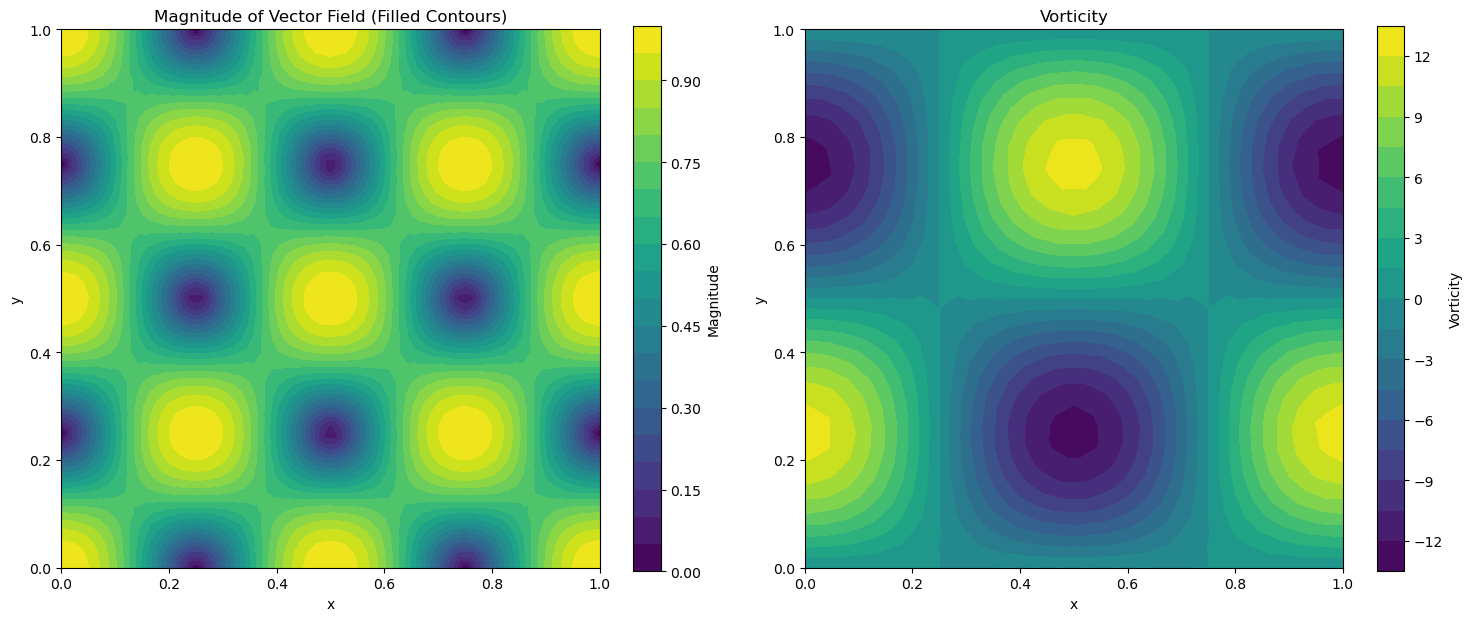

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation
import matplotlib.tri as tri

# Calculate the magnitude of the vector field
function_values_x = phi.getListOfSingleFields()[0].getCoefficientArray()
function_values_y = phi.getListOfSingleFields()[1].getCoefficientArray()

magnitude = np.sqrt(function_values_x**2 + function_values_y**2)

# Extract x and y coordinates from dof_coordinates
dof_coordinates = vectorSpace.tabulate_dof_coordinates()
x_coords = dof_coordinates[:, 0]
y_coords = dof_coordinates[:, 1]

vorticity_values = vorticity.getCoefficientArray()
# Create triangulation for irregular grid
triang = Triangulation(x_coords, y_coords)

# Create the contour plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Filled contour plot
contour_filled = ax1.tricontourf(triang, magnitude, levels=20, cmap='viridis')
ax1.set_title('Magnitude of Vector Field (Filled Contours)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')
plt.colorbar(contour_filled, ax=ax1, label='Magnitude')

# Plot 1: Filled contour plot
vorticity_filled = ax2.tricontourf(triang, vorticity_values, levels=20, cmap='viridis')
ax2.set_title('Vorticity')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')
plt.colorbar(vorticity_filled, ax=ax2, label='Vorticity')

plt.tight_layout()
plt.show()